### Importing Libraries

In [128]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler

### Reading our dataset

In [129]:
df = pd.read_csv( '../data/raw/Heart-Disease-Patients-Records.csv' )

In [130]:
df.head()

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
0,52,male,typical angina,125,212,lower than 120mg/ml,ST-T wave abnormality,168,no,1.0,downsloping,2,reversable defect,Diagnosed
1,53,male,typical angina,140,203,higher than 120mg/ml,normal,155,yes,3.1,upsloping,0,reversable defect,Diagnosed
2,70,male,typical angina,145,174,lower than 120mg/ml,ST-T wave abnormality,125,yes,2.6,upsloping,0,reversable defect,Diagnosed
3,61,male,typical angina,148,203,lower than 120mg/ml,ST-T wave abnormality,161,no,0.0,downsloping,1,reversable defect,Diagnosed
4,62,female,typical angina,138,294,higher than 120mg/ml,ST-T wave abnormality,106,no,1.9,flat,3,fixed defect,Diagnosed


In [131]:
df.shape

(1025, 14)

### EDA

#### Check for nulls or duplications

In [132]:
df.isna().sum()

age                         0
sex                         0
chest_pain_type             0
resisting_blood_pressure    0
cholesterol_level           0
fasting_blood_sugar         0
rest_ecg                    0
max_heart_rate_achieved     0
exercise_induced_angina     0
st_depression               0
st_slope                    0
num_major_vessels           0
thalassemia                 0
diagnosis                   0
dtype: int64

In [133]:
df.duplicated().sum()

np.int64(723)

<h1>Removes the duplicated data </h1>

In [134]:
df = df.drop_duplicates()

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       302 non-null    int64  
 1   sex                       302 non-null    object 
 2   chest_pain_type           302 non-null    object 
 3   resisting_blood_pressure  302 non-null    int64  
 4   cholesterol_level         302 non-null    int64  
 5   fasting_blood_sugar       302 non-null    object 
 6   rest_ecg                  302 non-null    object 
 7   max_heart_rate_achieved   302 non-null    int64  
 8   exercise_induced_angina   302 non-null    object 
 9   st_depression             302 non-null    float64
 10  st_slope                  302 non-null    object 
 11  num_major_vessels         302 non-null    int64  
 12  thalassemia               302 non-null    object 
 13  diagnosis                 302 non-null    object 
dtypes: float64(1), 

In [136]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resisting_blood_pressure',
       'cholesterol_level', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'diagnosis'],
      dtype='object')

# Data Visulaization

### Distribution & outliers

# Skewness

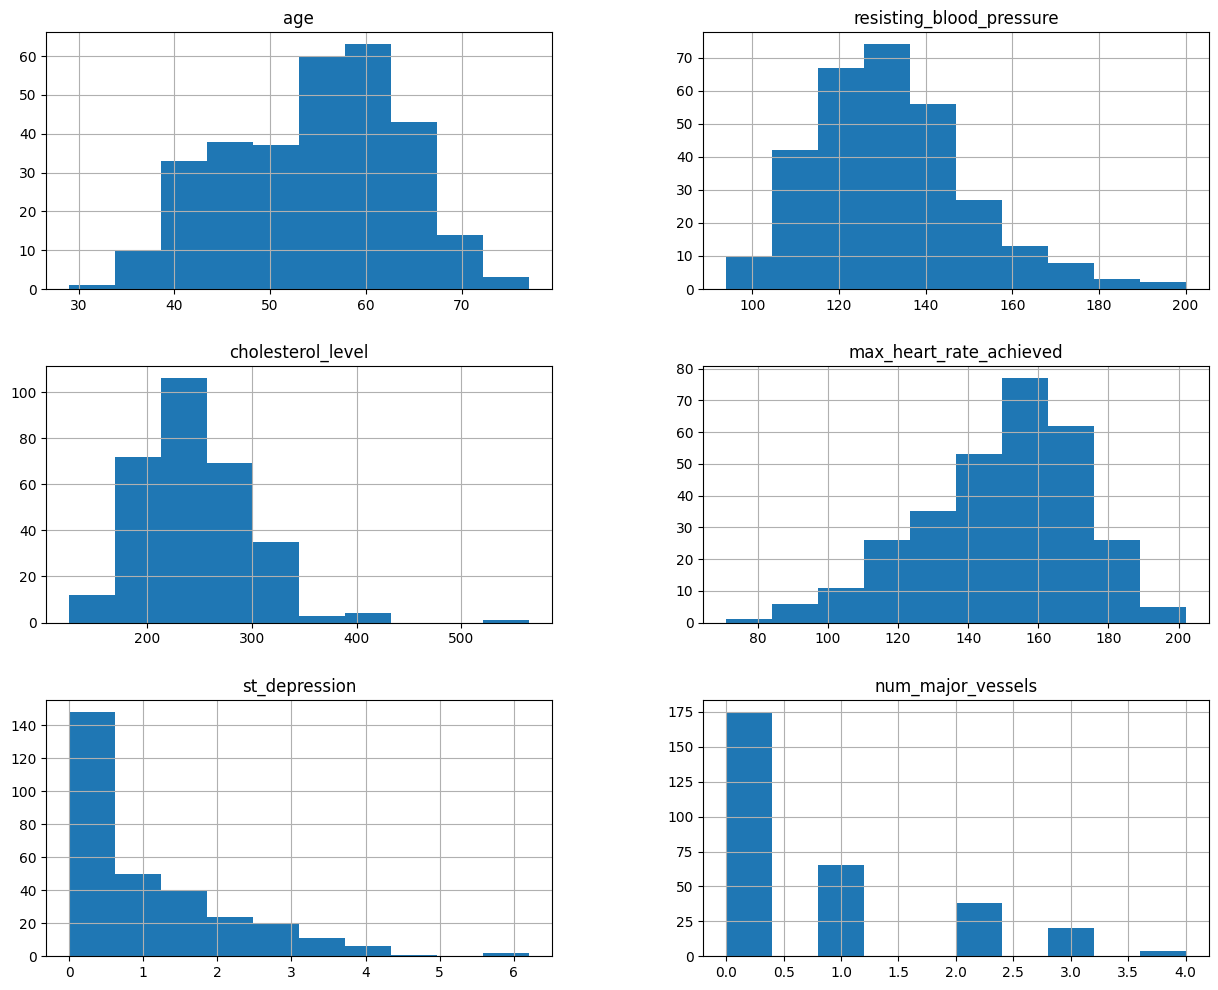

In [137]:
df.hist( figsize= ( 15, 12 ) );

### SME Subject Matter Expert

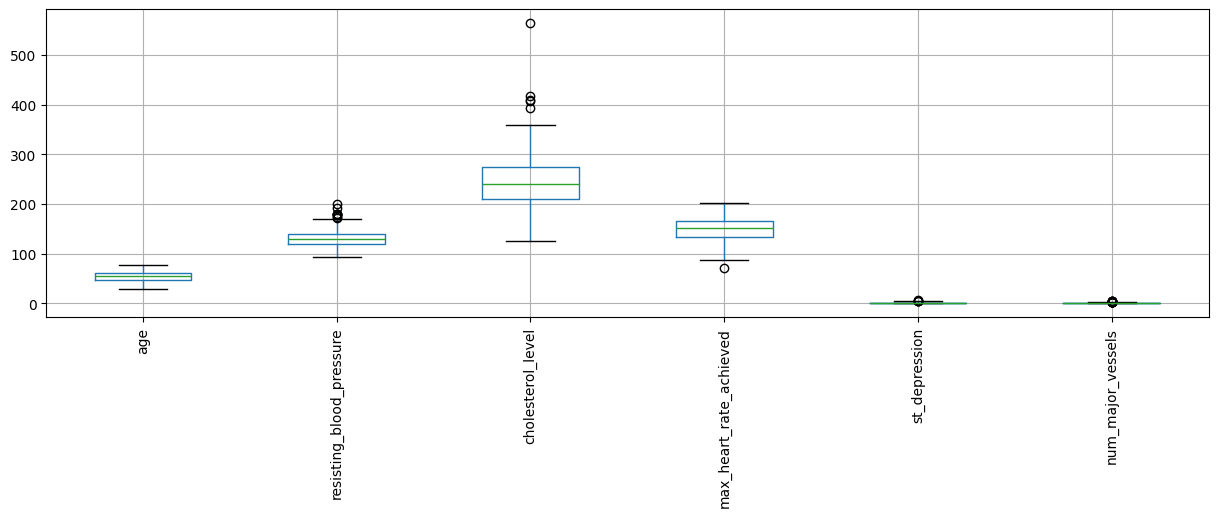

In [138]:
df.boxplot( figsize = (  15, 4  ) )
plt.xticks( rotation = 90 );

In [139]:
df.shape

(302, 14)

In [140]:
df['cholesterol_level'].describe()

count    302.000000
mean     246.500000
std       51.753489
min      126.000000
25%      211.000000
50%      240.500000
75%      274.750000
max      564.000000
Name: cholesterol_level, dtype: float64

### Scaling

### log

In [141]:
from sklearn.preprocessing import LabelEncoder

In [142]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['chest_pain_type'] = le.fit_transform(df['chest_pain_type'])	
df['rest_ecg'] = le.fit_transform(df['rest_ecg'])
df['st_slope'] = le.fit_transform(df['st_slope'])
df['thalassemia'] = le.fit_transform(df['thalassemia'])
df['diagnosis'] = le.fit_transform(df['diagnosis'])
df['exercise_induced_angina'] = le.fit_transform(df['exercise_induced_angina'])
df['fasting_blood_sugar'] = le.fit_transform(df['fasting_blood_sugar'])

In [143]:
scaler = StandardScaler()

In [144]:
scaler.fit(df)

StandardScaler()

In [145]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resisting_blood_pressure',
       'cholesterol_level', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'diagnosis'],
      dtype='object')

In [146]:
scaled_df = pd.DataFrame( scaler.transform( df ), columns = df.columns )
scaled_df

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
0,-0.267966,0.682656,0.880562,-0.376556,-0.667728,0.418446,-0.993444,0.806035,-0.698344,-0.037124,-0.979514,1.274980,1.215097,-1.090140
1,-0.157260,0.682656,0.880562,0.478910,-0.841918,-2.389793,1.020113,0.237495,1.431958,1.773958,2.271182,-0.714911,1.215097,-1.090140
2,1.724733,0.682656,0.880562,0.764066,-1.403197,0.418446,-0.993444,-1.074521,1.431958,1.342748,2.271182,-0.714911,1.215097,-1.090140
3,0.728383,0.682656,0.880562,0.935159,-0.841918,0.418446,-0.993444,0.499898,-0.698344,-0.899544,-0.979514,0.280034,1.215097,-1.090140
4,0.839089,-1.464866,0.880562,0.364848,0.919336,-2.389793,-0.993444,-1.905464,-0.698344,0.739054,0.645834,2.269926,-0.858119,-1.090140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,1.503322,-1.464866,-0.162300,-0.661712,-0.687083,0.418446,1.020113,-1.511859,-0.698344,0.394086,0.645834,-0.714911,-0.858119,0.917313
298,-1.153610,-1.464866,-0.162300,-1.346085,-2.041893,0.418446,-0.993444,1.112172,-0.698344,-0.382092,0.645834,-0.714911,-0.858119,0.917313
299,-0.267966,0.682656,0.880562,-0.205463,0.164513,0.418446,-0.993444,0.499898,1.431958,-0.899544,-0.979514,0.280034,1.215097,-1.090140
300,0.506972,0.682656,-2.248024,1.619532,0.512893,0.418446,1.020113,-1.074521,-0.698344,-0.899544,-0.979514,-0.714911,-0.858119,-1.090140


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(1, 0, 'age'),
  Text(2, 0, 'sex'),
  Text(3, 0, 'chest_pain_type'),
  Text(4, 0, 'resisting_blood_pressure'),
  Text(5, 0, 'cholesterol_level'),
  Text(6, 0, 'fasting_blood_sugar'),
  Text(7, 0, 'rest_ecg'),
  Text(8, 0, 'max_heart_rate_achieved'),
  Text(9, 0, 'exercise_induced_angina'),
  Text(10, 0, 'st_depression'),
  Text(11, 0, 'st_slope'),
  Text(12, 0, 'num_major_vessels'),
  Text(13, 0, 'thalassemia'),
  Text(14, 0, 'diagnosis')])

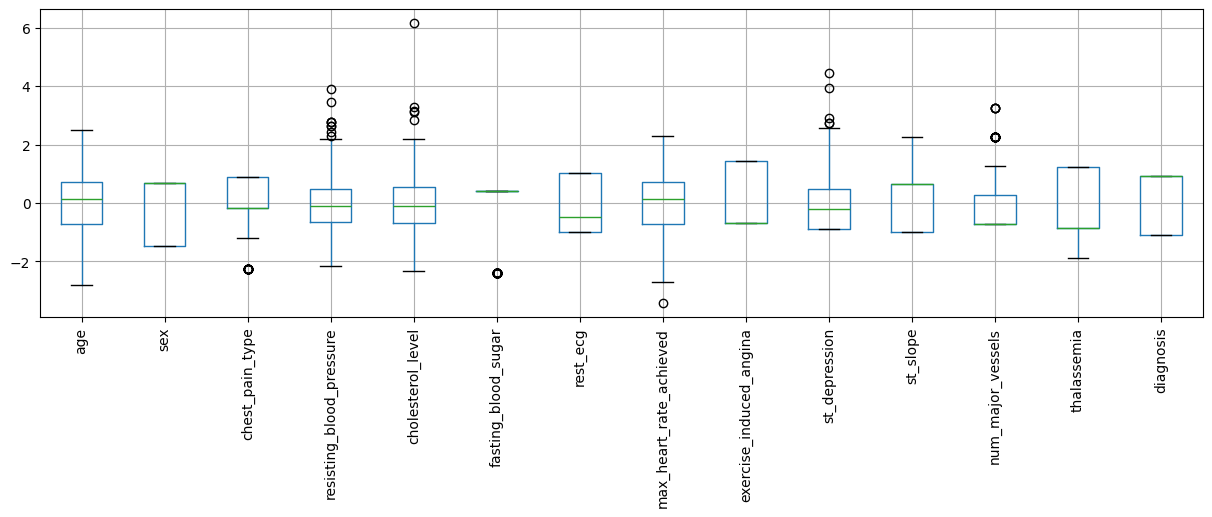

In [147]:
scaled_df.boxplot( figsize = (  15, 4  ) )
plt.xticks( rotation = 90 )